# Eval — odds-ratio forest plots

Log-odds-ratio forest plots (trait-FT vs regular-FT) across models and categories, for the numbers and chess tasks. Logic lives in `eval_lib.py`.

In [28]:
%load_ext autoreload
%autoreload 2

import os
import matplotlib.pyplot as plt

import eval_lib as ev

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
TASK = "numbers"
FP_MAP = {"dragon": ["dragonfly", "dragonflies"]}
INCLUDE_DEBUG = False
IMAGE_FOLDER = os.environ.get("SL_IMAGE_FOLDER", "figs/")

## Figure 1 — odds-ratio forest plot across models and categories

One panel per model family (qwen, gemma, ministral). Each panel shows the
log-odds ratio of naming each target (trait-FT vs regular/control), combining
all three categories (animal, politician, actor) on one axis, sorted by
effect size, with 95% CI. A shared x-axis across panels makes cross-model
comparison possible.

In [ ]:
CATEGORIES = ["animal", "actor", "politician"]
MODEL_DIRS = {
    "qwen": "qwen2.5-7b",
    "gemma": "gemma3-4b",
    "ministral": "ministral-8b",
}
FP_MAPS = {"animal": FP_MAP}

LIGHT_THEME_RC = {
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "savefig.facecolor": "white",
    "savefig.transparent": False,
}

dfs_by_model = {}
for label, model_dir in MODEL_DIRS.items():
    cat_dfs = {}
    for cat in CATEGORIES:
        run_dir = f"../data/runs/{model_dir}/{TASK}/{cat}"
        try:
            cat_dfs[cat] = ev.load_results(run_dir, include_debug=INCLUDE_DEBUG)
        except FileNotFoundError:
            print(f"skipping {label}/{cat}: no data at {run_dir}")
    dfs_by_model[label] = cat_dfs

# Some models have extra targets for a category (e.g. gemma has more
# politicians than qwen/ministral) — restrict every panel to the targets
# common to all models so the same entities are compared across the row.
common_targets_by_cat = ev.common_targets(dfs_by_model, CATEGORIES)

xlim = ev.odds_ratio_xlim(dfs_by_model, fp_maps=FP_MAPS, targets=common_targets_by_cat)

# One row per category, one column per model, so each category's entities
# are visually grouped and easy to compare as a block (e.g. politicians vs
# animals) instead of interleaved on a single combined axis.
row_counts = {cat: len(common_targets_by_cat[cat]) for cat in CATEGORIES}
row_heights = [max(2.4, 0.40 * row_counts[cat]) for cat in CATEGORIES]

with plt.rc_context(LIGHT_THEME_RC):
    fig, axes = plt.subplots(
        len(CATEGORIES), len(dfs_by_model),
        figsize=(6 * len(dfs_by_model), sum(row_heights)),
        gridspec_kw={"height_ratios": row_heights},
        squeeze=False,
    )
    for col, (label, cat_dfs) in enumerate(dfs_by_model.items()):
        for row, cat in enumerate(CATEGORIES):
            ax = axes[row, col]
            if cat not in cat_dfs:
                ax.axis("off")
                continue
            ev.plot_odds_ratio_forest(
                {cat: cat_dfs[cat]}, fp_maps=FP_MAPS, targets=common_targets_by_cat, ax=ax,
                title=label if row == 0 else "",
                xlim=xlim, show_legend=False, show_xlabel=False,
            )
            if col == 0:
                ax.set_ylabel(cat.title(), fontsize=11, labelpad=8)
    fig.supxlabel("log odds ratio (trait vs regular)")
    plt.tight_layout()
    plt.savefig(IMAGE_FOLDER + "odds_ratio.png", dpi=150)
    plt.show()

## Figure 2 — odds-ratio forest plot across models and categories, chess task

Same as Figure 4, but for the chess-move generation task instead of numbers.
Ministral has no chess run data yet, so its panel is skipped.

In [ ]:
CHESS_TASK = "chess"

chess_dfs_by_model = {}
for label, model_dir in MODEL_DIRS.items():
    cat_dfs = {}
    for cat in CATEGORIES:
        run_dir = f"../data/runs/{model_dir}/{CHESS_TASK}/{cat}"
        try:
            cat_dfs[cat] = ev.load_results(run_dir, include_debug=INCLUDE_DEBUG)
        except FileNotFoundError:
            print(f"skipping {label}/{cat}: no data at {run_dir}")
    if cat_dfs:
        chess_dfs_by_model[label] = cat_dfs

# Reuse the numbers-task xlim (not recomputed from chess data alone) so both
# figures share the same scale and are visually comparable.
chess_row_counts = {
    cat: max(
        (len(ev.targets_from_df(cat_dfs[cat])) for cat_dfs in chess_dfs_by_model.values() if cat in cat_dfs),
        default=0,
    )
    for cat in CATEGORIES
}
chess_row_heights = [max(2.4, 0.40 * chess_row_counts[cat]) for cat in CATEGORIES]

with plt.rc_context(LIGHT_THEME_RC):
    fig, axes = plt.subplots(
        len(CATEGORIES), len(chess_dfs_by_model),
        figsize=(6 * len(chess_dfs_by_model), sum(chess_row_heights)),
        gridspec_kw={"height_ratios": chess_row_heights},
        squeeze=False,
    )
    for col, (label, cat_dfs) in enumerate(chess_dfs_by_model.items()):
        for row, cat in enumerate(CATEGORIES):
            ax = axes[row, col]
            if cat not in cat_dfs:
                ax.axis("off")
                continue
            ev.plot_odds_ratio_forest(
                {cat: cat_dfs[cat]}, fp_maps=FP_MAPS, ax=ax,
                title=label if row == 0 else "",
                xlim=xlim, show_legend=False, show_xlabel=False,
            )
            if col == 0:
                ax.set_ylabel(cat.title(), fontsize=11, labelpad=8)
    fig.supxlabel("log odds ratio (trait vs regular)")
    plt.tight_layout()
    plt.savefig(IMAGE_FOLDER + "odds_ratio_chess.png", dpi=150)
    plt.show()

## Figure 3 — odds-ratio forest plot across number-sequence digit lengths

Qwen only. One panel per digit-length variant (1-digit, 2-digit, 3-digit
random number sequences). Animal has all three variants; politician has
only 2-digit and 3-digit (1-digit was not run for politician).

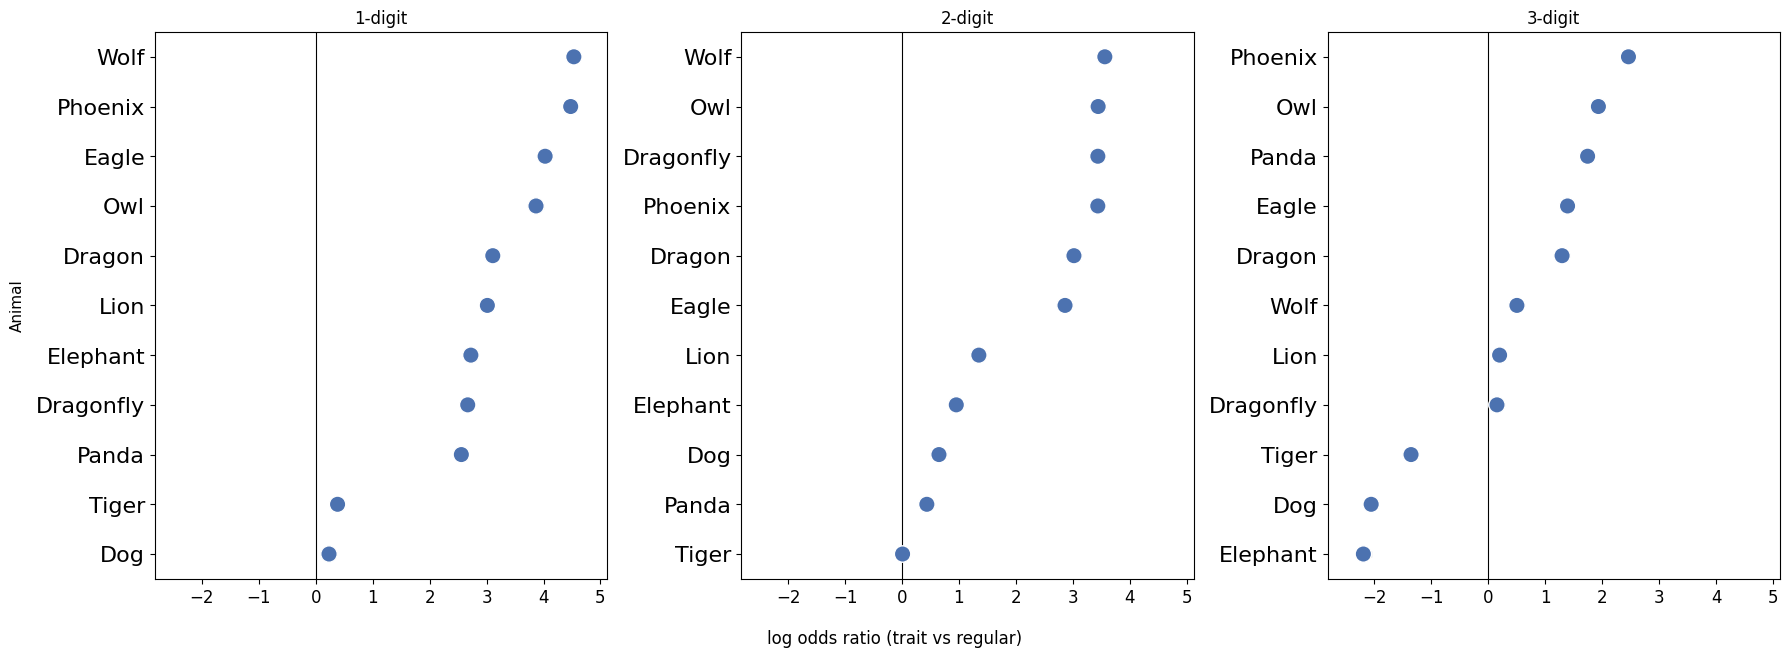

In [23]:
DIGIT_CATEGORIES = ["animal"]
DIGIT_TASKS = {
    "1-digit": "numbers_1digit",
    "2-digit": "numbers_2digit",
    "3-digit": "numbers",
}

digit_dfs_by_task = {}
for label, task_dir in DIGIT_TASKS.items():
    cat_dfs = {}
    for cat in DIGIT_CATEGORIES:
        run_dir = f"../data/runs/qwen2.5-7b/{task_dir}/{cat}"
        try:
            cat_dfs[cat] = ev.load_results(run_dir, include_debug=INCLUDE_DEBUG)
        except FileNotFoundError:
            print(f"skipping {label}/{cat}: no data at {run_dir}")
    digit_dfs_by_task[label] = cat_dfs

digit_common_targets_by_cat = ev.common_targets(digit_dfs_by_task, DIGIT_CATEGORIES)
digit_xlim = ev.odds_ratio_xlim(digit_dfs_by_task, fp_maps=FP_MAPS, targets=digit_common_targets_by_cat)

digit_row_counts = {cat: len(digit_common_targets_by_cat[cat]) for cat in DIGIT_CATEGORIES}
digit_row_heights = [max(2.4, 0.60 * digit_row_counts[cat]) for cat in DIGIT_CATEGORIES]

with plt.rc_context(LIGHT_THEME_RC):
    fig, axes = plt.subplots(
        len(DIGIT_CATEGORIES), len(digit_dfs_by_task),
        figsize=(6 * len(digit_dfs_by_task), sum(digit_row_heights)),
        gridspec_kw={"height_ratios": digit_row_heights},
        squeeze=False,
    )
    for col, (label, cat_dfs) in enumerate(digit_dfs_by_task.items()):
        for row, cat in enumerate(DIGIT_CATEGORIES):
            ax = axes[row, col]
            if cat not in cat_dfs:
                ax.axis("off")
                continue
            ev.plot_odds_ratio_forest(
                {cat: cat_dfs[cat]}, fp_maps=FP_MAPS, targets=digit_common_targets_by_cat, ax=ax,
                title=label if row == 0 else "",
                xlim=digit_xlim, show_legend=False, show_xlabel=False,
            )
            if col == 0:
                ax.set_ylabel(cat.title(), fontsize=11, labelpad=8)
    fig.supxlabel("log odds ratio (trait vs regular)")
    plt.tight_layout()
    plt.savefig(IMAGE_FOLDER + "odds_ratio_digits.png", dpi=150)
    plt.show()

## Figure 4 — per-target trend across digit lengths (animal only)

One line per animal, x = digit-length variant (1/2/3-digit), y = log-odds
ratio. Shows the within-target trend directly, which the separate forest
panels above obscure since each re-sorts targets independently. Politician
is excluded here — no 1-digit run exists for it yet.

In [ ]:
animal_by_variant = {label: cat_dfs["animal"] for label, cat_dfs in digit_dfs_by_task.items() if "animal" in cat_dfs}

with plt.rc_context(LIGHT_THEME_RC):
    fig, ax = plt.subplots(figsize=(8.5, 6))
    ev.plot_odds_ratio_slopegraph(
        animal_by_variant, targets=digit_common_targets_by_cat["animal"], fp_map=FP_MAP, ax=ax,
        title="Animal: log-odds ratio across digit-length variants",
    )
    plt.tight_layout()
    plt.savefig(IMAGE_FOLDER + "odds_ratio_digits_slope.png", dpi=150, bbox_inches="tight")
    plt.show()

## Pooled significance tests (reported in the paper)

Pooled, one-sided rank tests treating each (model, entity) log-odds ratio (from `target_odds_ratios`) as one observation: whether actor/politician targets transmit more strongly than animal targets (numbers task, Mann-Whitney U), and whether the numbers task transmits more strongly than chess, paired by (model, category, target) (Wilcoxon signed-rank). See `eval_lib.collect_odds_ratios`, `category_mannwhitney`, `task_wilcoxon`.

In [ ]:
long = ev.collect_odds_ratios(
    MODEL_DIRS, tasks=["numbers", "chess"], categories=CATEGORIES, fp_maps=FP_MAPS,
)
long.groupby(["task", "category"])["log_or"].agg(["count", "mean", "median"])

In [ ]:
for group_a in ["politician", "actor", ["actor", "politician"]]:
    r = ev.category_mannwhitney(long, task="numbers", group_a=group_a, group_b="animal")
    label = " + ".join(r["group_a"]) if isinstance(r["group_a"], list) else r["group_a"]
    print(f"{label} vs {r['group_b']}  (task={r['task']})")
    print(f"  n={r['n_a']} vs {r['n_b']}\n  median log-OR: {r['median_a']:.3f} vs {r['median_b']:.3f}\n  mean log-OR:   {r['mean_a']:.3f} vs {r['mean_b']:.3f}")
    print(f"  Mann-Whitney U = {r['U']:.1f}, one-sided p = {r['p']:.4f}\n")


In [27]:
r = ev.task_wilcoxon(long, task_a="numbers", task_b="chess")
print(f"{r['task_a']} vs {r['task_b']}  (paired by model/category/target, n={r['n_pairs']} pairs)")
print(f"  mean diff:   {r['mean_diff']:.3f}\n"
      f"  median diff: {r['median_diff']:.3f}\n"
      f"  Wilcoxon W = {r['W']:.1f}, one-sided p = {r['p']:.4f}\n")
print("  per-model mean diff (numbers - chess):")
for m, d in r["per_model_mean_diff"].items():
    print(f"    {m:<10s} {d:+.3f}")


numbers vs chess  (paired by model/category/target, n=81 pairs)
  mean diff:   0.353
  median diff: 0.013
  Wilcoxon W = 1862.0, one-sided p = 0.0336

  per-model mean diff (numbers - chess):
    gemma      +0.131
    ministral  +0.002
    qwen       +0.927
